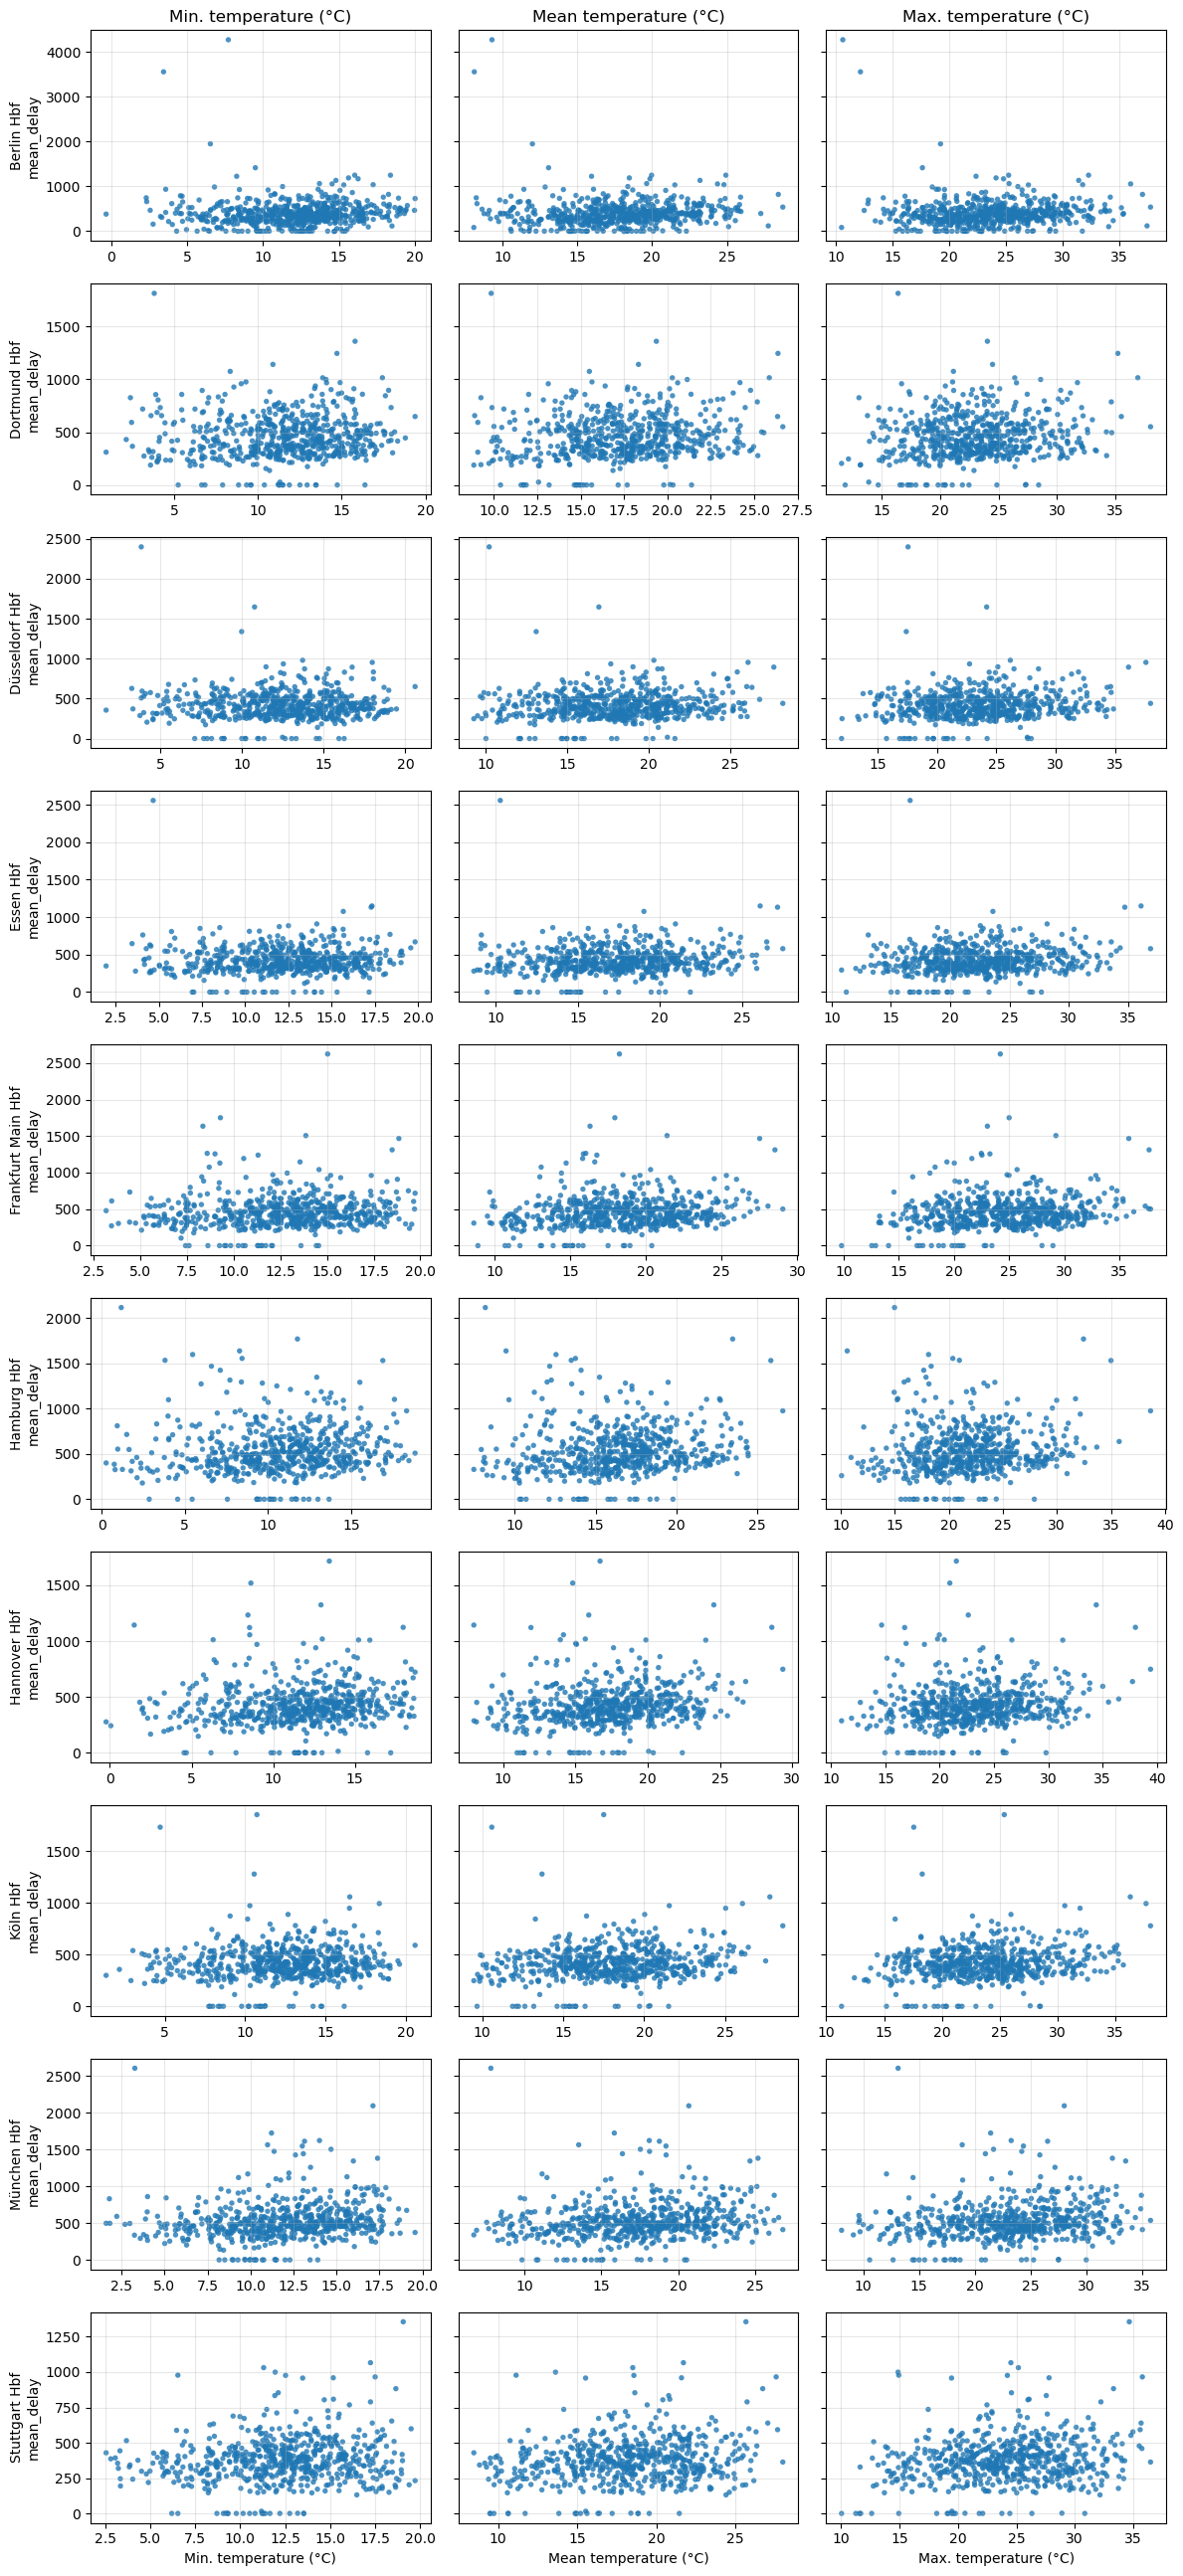

In [1]:
import glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "mean_delay"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")
        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()
#print("saved:", out_file)

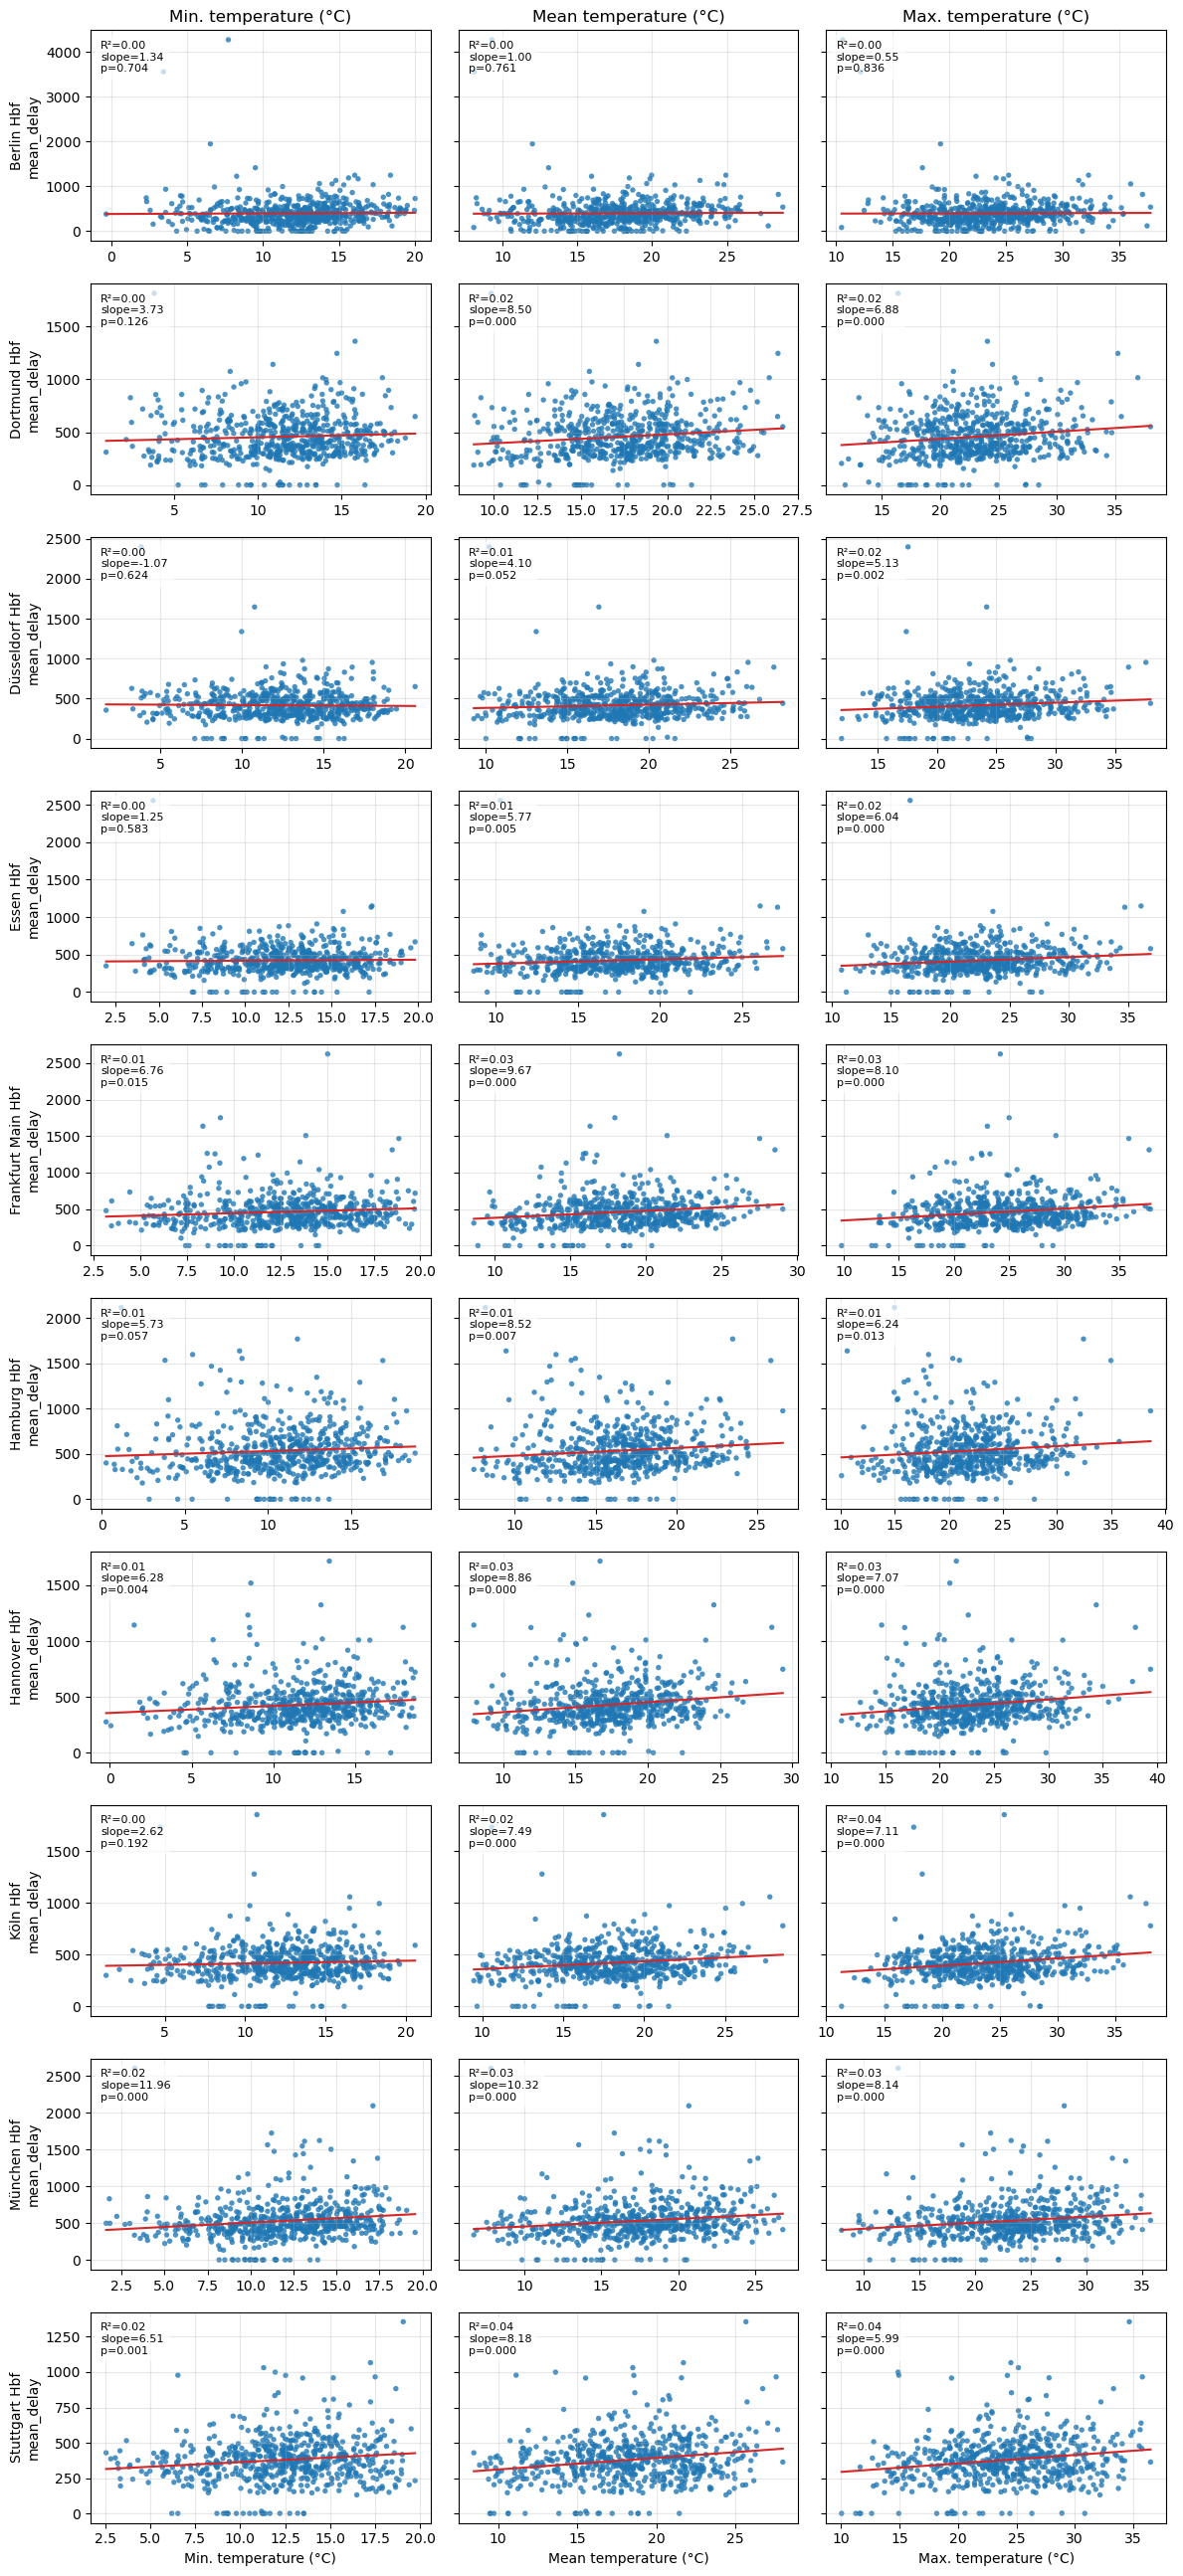

              city variable   n  slope  intercept      r    R2  p_value  stderr_slope
        Berlin Hbf       tn 609  1.335    383.436  0.015 0.000    0.704         3.518
        Berlin Hbf       tg 609  0.996    381.696  0.012 0.000    0.761         3.267
        Berlin Hbf       tx 609  0.549    386.483  0.008 0.000    0.836         2.644
      Dortmund Hbf       tn 610  3.734    414.071  0.062 0.004    0.126         2.439
      Dortmund Hbf       tg 610  8.502    309.325  0.144 0.021    0.000         2.374
      Dortmund Hbf       tx 610  6.879    298.488  0.147 0.022    0.000         1.881
    Düsseldorf Hbf       tn 610 -1.067    429.351 -0.020 0.000    0.624         2.178
    Düsseldorf Hbf       tg 610  4.100    342.388  0.079 0.006    0.052         2.103
    Düsseldorf Hbf       tx 610  5.127    295.439  0.123 0.015    0.002         1.679
         Essen Hbf       tn 610  1.246    406.686  0.022 0.000    0.583         2.271
         Essen Hbf       tg 610  5.775    321.889  0.1

In [2]:
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "mean_delay"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)
results = []

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")

        # --- linear regression (rows with both values present) ---
        sub = d[[var, DELAY_COL]].dropna()
        if len(sub) > 2:
            res = stats.linregress(sub[var], sub[DELAY_COL])
            xs = np.array([sub[var].min(), sub[var].max()])
            ax.plot(xs, res.intercept + res.slope * xs, color="C3", lw=1.5)
            ax.text(0.03, 0.95,
                    f"R²={res.rvalue**2:.2f}\nslope={res.slope:.2f}\np={res.pvalue:.3f}",
                    transform=ax.transAxes, va="top", fontsize=8,
                    bbox=dict(fc="white", ec="none", alpha=0.7))
            results.append({"city": city, "variable": var, "n": len(sub),
                            "slope": res.slope, "intercept": res.intercept,
                            "r": res.rvalue, "R2": res.rvalue**2,
                            "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()

summary = pd.DataFrame(results)
print(summary.round(3).to_string(index=False))
#summary.to_csv(csv_dir / "regression_summary.csv", index=False)

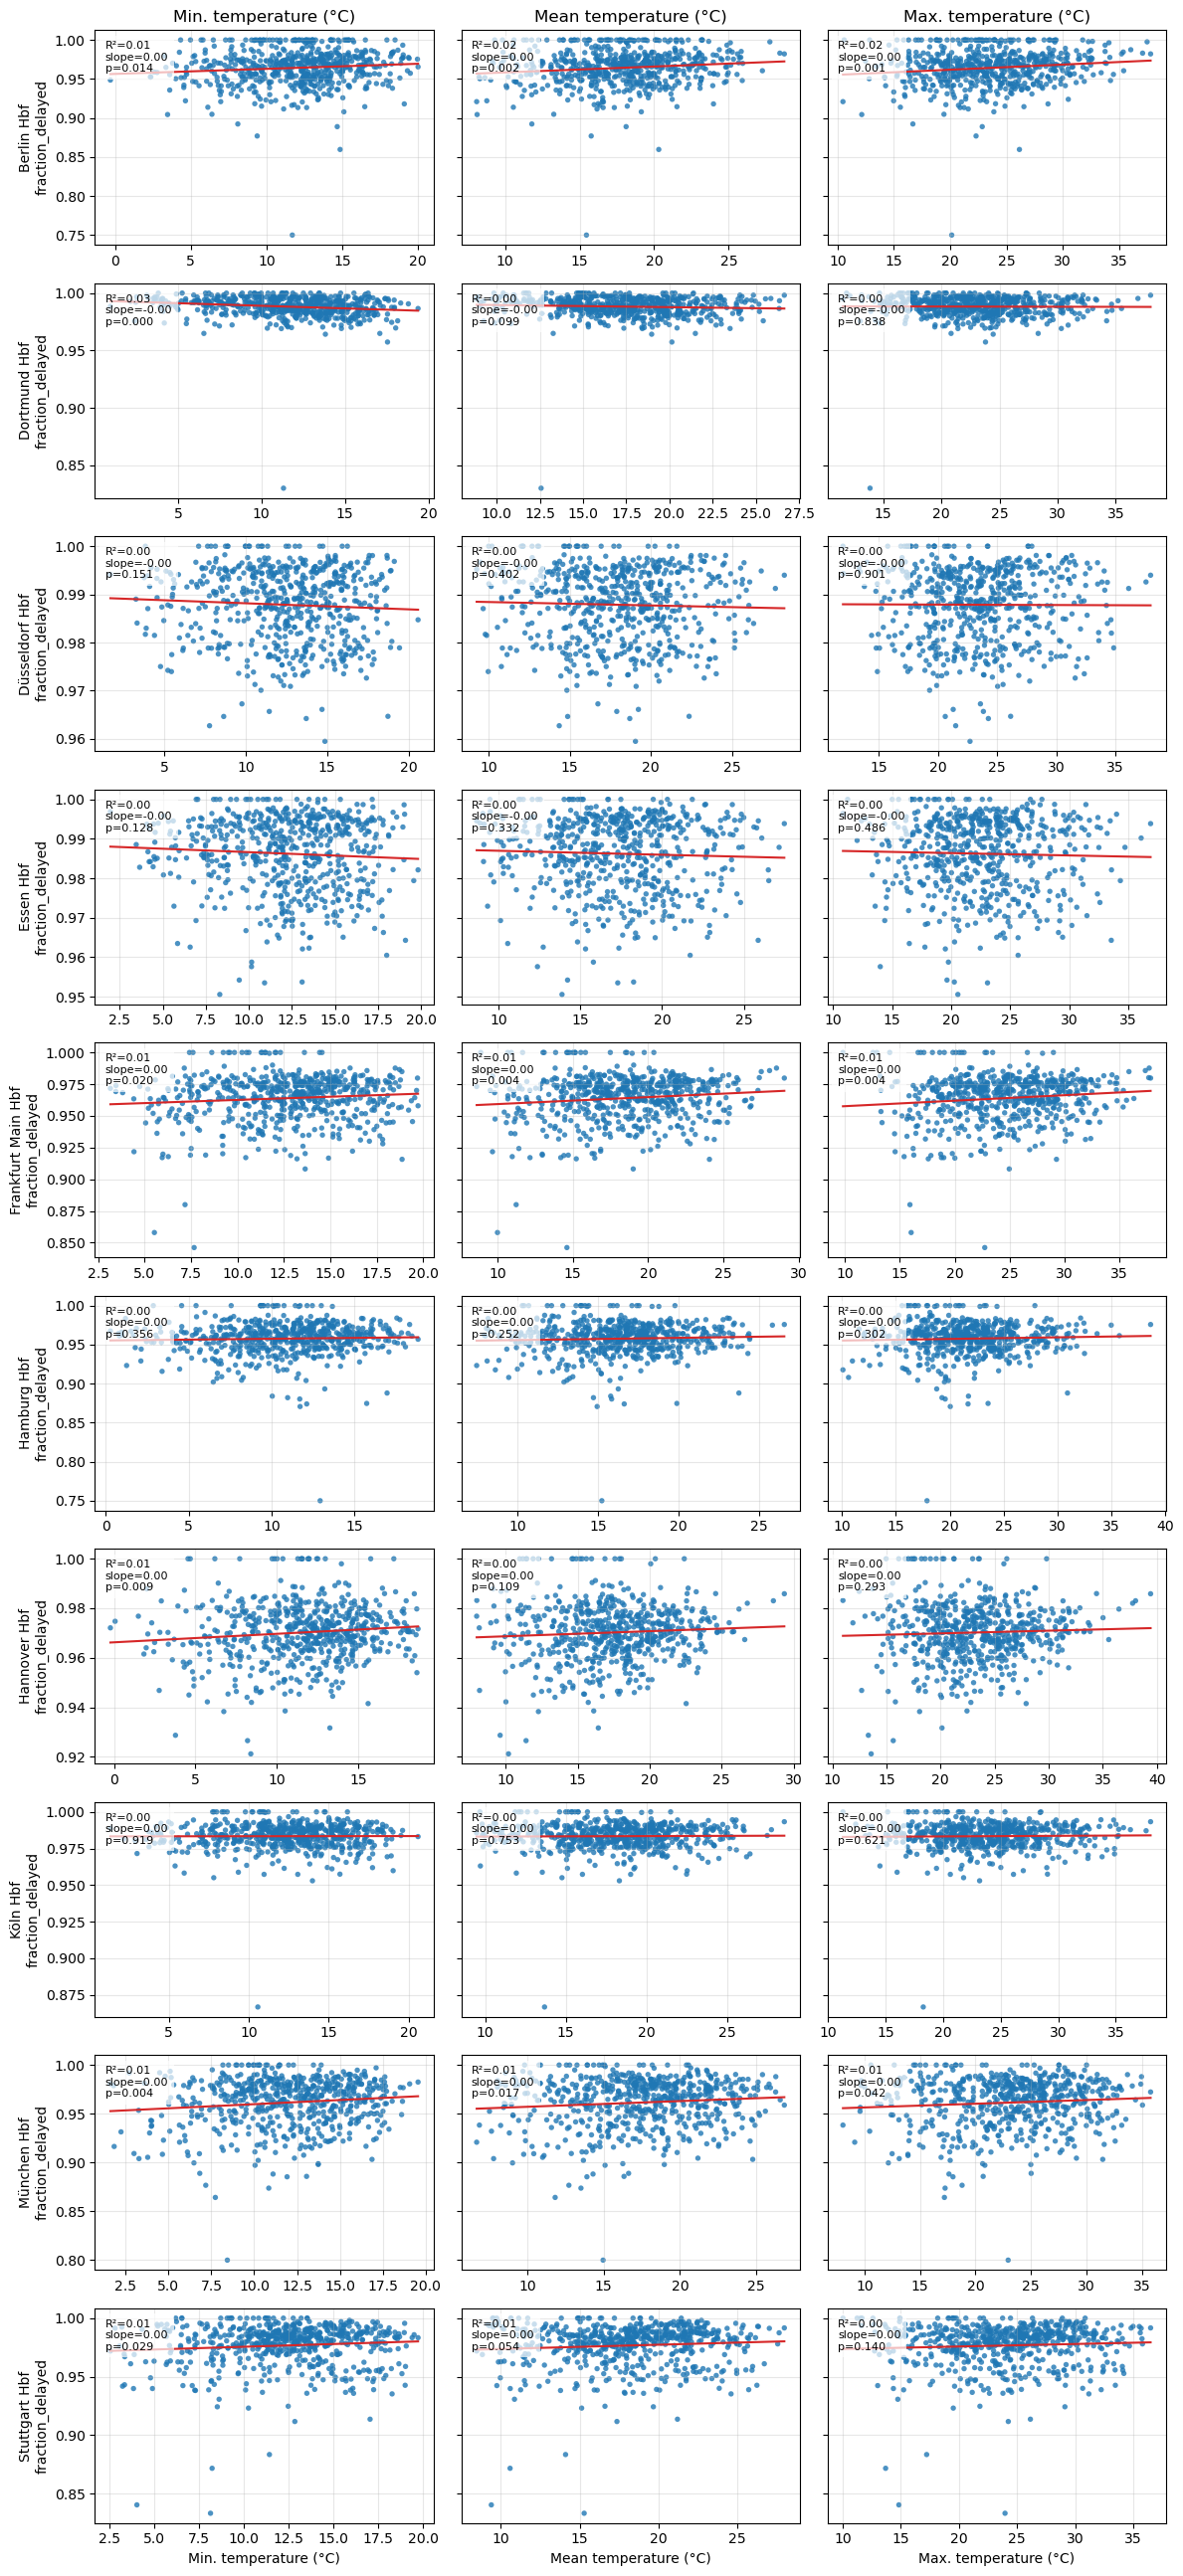

              city variable   n  slope  intercept      r    R2  p_value  stderr_slope
        Berlin Hbf       tn 609  0.001      0.956  0.100 0.010    0.014           0.0
        Berlin Hbf       tg 609  0.001      0.951  0.124 0.015    0.002           0.0
        Berlin Hbf       tx 609  0.001      0.949  0.134 0.018    0.001           0.0
      Dortmund Hbf       tn 610 -0.000      0.993 -0.162 0.026    0.000           0.0
      Dortmund Hbf       tg 610 -0.000      0.991 -0.067 0.004    0.099           0.0
      Dortmund Hbf       tx 610 -0.000      0.989 -0.008 0.000    0.838           0.0
    Düsseldorf Hbf       tn 610 -0.000      0.989 -0.058 0.003    0.151           0.0
    Düsseldorf Hbf       tg 610 -0.000      0.989 -0.034 0.001    0.402           0.0
    Düsseldorf Hbf       tx 610 -0.000      0.988 -0.005 0.000    0.901           0.0
         Essen Hbf       tn 610 -0.000      0.988 -0.062 0.004    0.128           0.0
         Essen Hbf       tg 610 -0.000      0.988 -0.0

In [3]:
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "fraction_delayed"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)
results = []

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")

        # --- linear regression (rows with both values present) ---
        sub = d[[var, DELAY_COL]].dropna()
        if len(sub) > 2:
            res = stats.linregress(sub[var], sub[DELAY_COL])
            xs = np.array([sub[var].min(), sub[var].max()])
            ax.plot(xs, res.intercept + res.slope * xs, color="C3", lw=1.5)
            ax.text(0.03, 0.95,
                    f"R²={res.rvalue**2:.2f}\nslope={res.slope:.2f}\np={res.pvalue:.3f}",
                    transform=ax.transAxes, va="top", fontsize=8,
                    bbox=dict(fc="white", ec="none", alpha=0.7))
            results.append({"city": city, "variable": var, "n": len(sub),
                            "slope": res.slope, "intercept": res.intercept,
                            "r": res.rvalue, "R2": res.rvalue**2,
                            "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()

summary = pd.DataFrame(results)
print(summary.round(3).to_string(index=False))
#summary.to_csv(csv_dir / "regression_summary.csv", index=False)

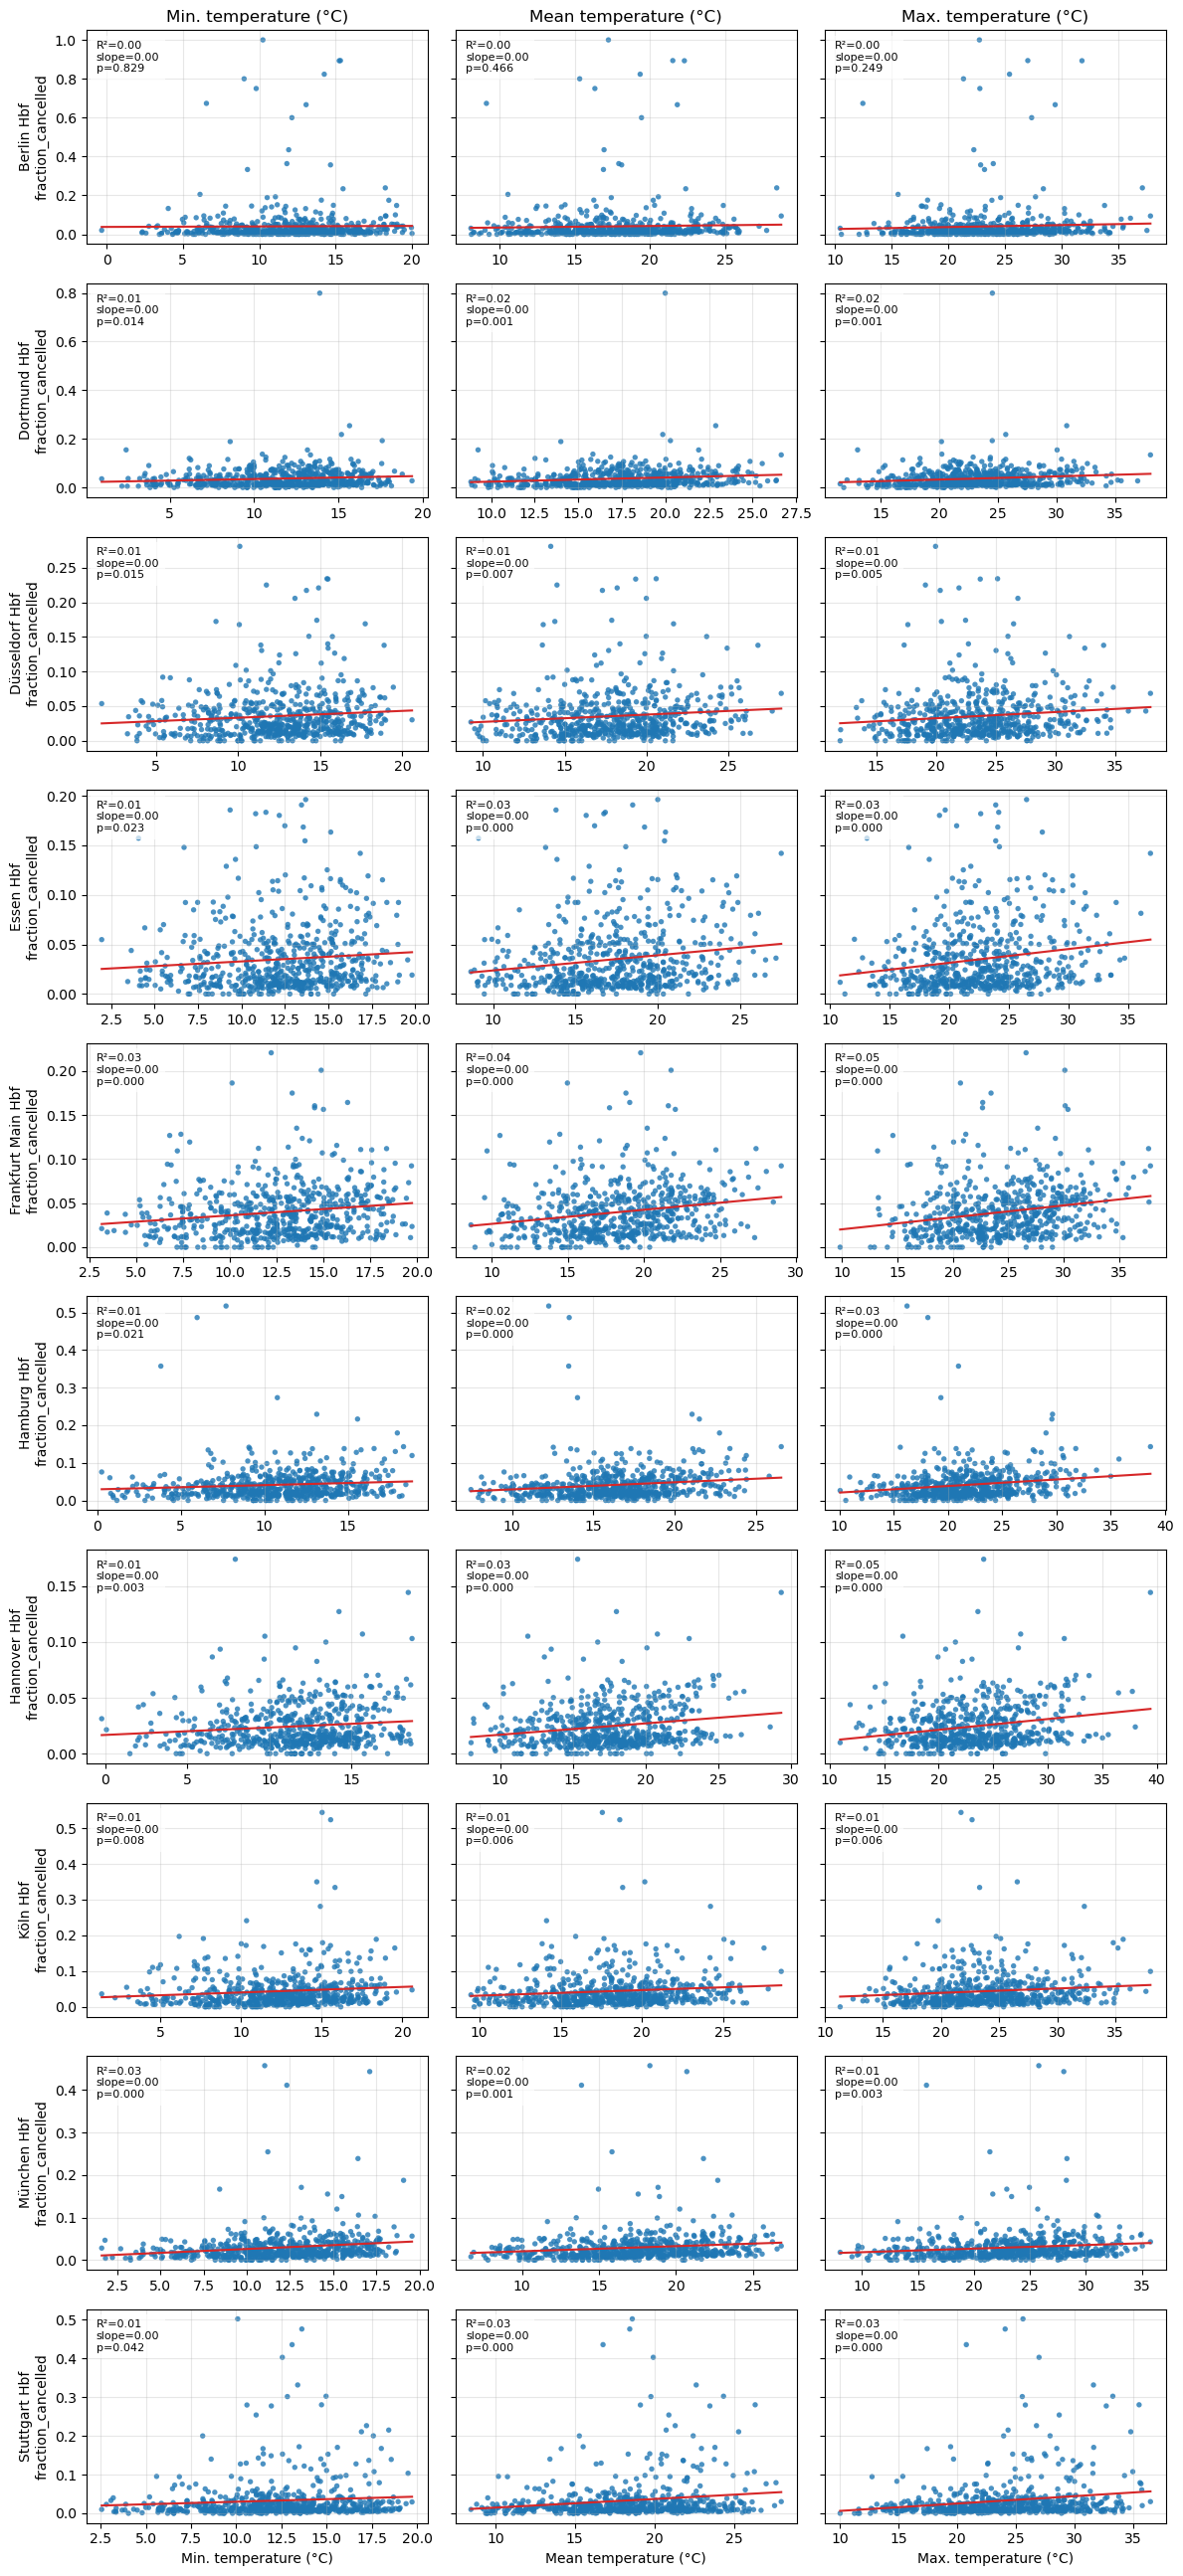

              city variable   n  slope  intercept     r    R2  p_value  stderr_slope
        Berlin Hbf       tn 610  0.000      0.038 0.009 0.000    0.829         0.001
        Berlin Hbf       tg 610  0.001      0.027 0.030 0.001    0.466         0.001
        Berlin Hbf       tx 610  0.001      0.017 0.047 0.002    0.249         0.001
      Dortmund Hbf       tn 610  0.001      0.022 0.099 0.010    0.014         0.001
      Dortmund Hbf       tg 610  0.002      0.007 0.136 0.019    0.001         0.001
      Dortmund Hbf       tx 610  0.001      0.007 0.132 0.017    0.001         0.000
    Düsseldorf Hbf       tn 610  0.001      0.023 0.098 0.010    0.015         0.000
    Düsseldorf Hbf       tg 610  0.001      0.017 0.108 0.012    0.007         0.000
    Düsseldorf Hbf       tx 610  0.001      0.015 0.115 0.013    0.005         0.000
         Essen Hbf       tn 610  0.001      0.023 0.092 0.008    0.023         0.000
         Essen Hbf       tg 610  0.002      0.008 0.163 0.027    

In [4]:
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
#out_file = csv_dir / "delay_vs_temperature.png"
DELAY_COL = "fraction_cancelled"          # or "fraction_delayed"
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

files = sorted(csv_dir.glob("*.csv"))
n = len(files)
results = []

fig, axes = plt.subplots(n, 3, figsize=(12, 2.6 * n), sharey="row", squeeze=False)

for i, f in enumerate(files):
    d = pd.read_csv(f, parse_dates=["date"])
    city = f.stem.replace("_", " ")
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        ax.scatter(d[var], d[DELAY_COL], s=15, alpha=0.8, edgecolor="none")

        # --- linear regression (rows with both values present) ---
        sub = d[[var, DELAY_COL]].dropna()
        if len(sub) > 2:
            res = stats.linregress(sub[var], sub[DELAY_COL])
            xs = np.array([sub[var].min(), sub[var].max()])
            ax.plot(xs, res.intercept + res.slope * xs, color="C3", lw=1.5)
            ax.text(0.03, 0.95,
                    f"R²={res.rvalue**2:.2f}\nslope={res.slope:.2f}\np={res.pvalue:.3f}",
                    transform=ax.transAxes, va="top", fontsize=8,
                    bbox=dict(fc="white", ec="none", alpha=0.7))
            results.append({"city": city, "variable": var, "n": len(sub),
                            "slope": res.slope, "intercept": res.intercept,
                            "r": res.rvalue, "R2": res.rvalue**2,
                            "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(f"{city}\n{DELAY_COL}")
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == n - 1:
            ax.set_xlabel(TEMP_LABELS[var])

fig.tight_layout()
#fig.savefig(out_file, dpi=150)
plt.show()

summary = pd.DataFrame(results)
print(summary.round(3).to_string(index=False))
#summary.to_csv(csv_dir / "regression_summary.csv", index=False)

### Now combine all the data and look only for T > 25 °C

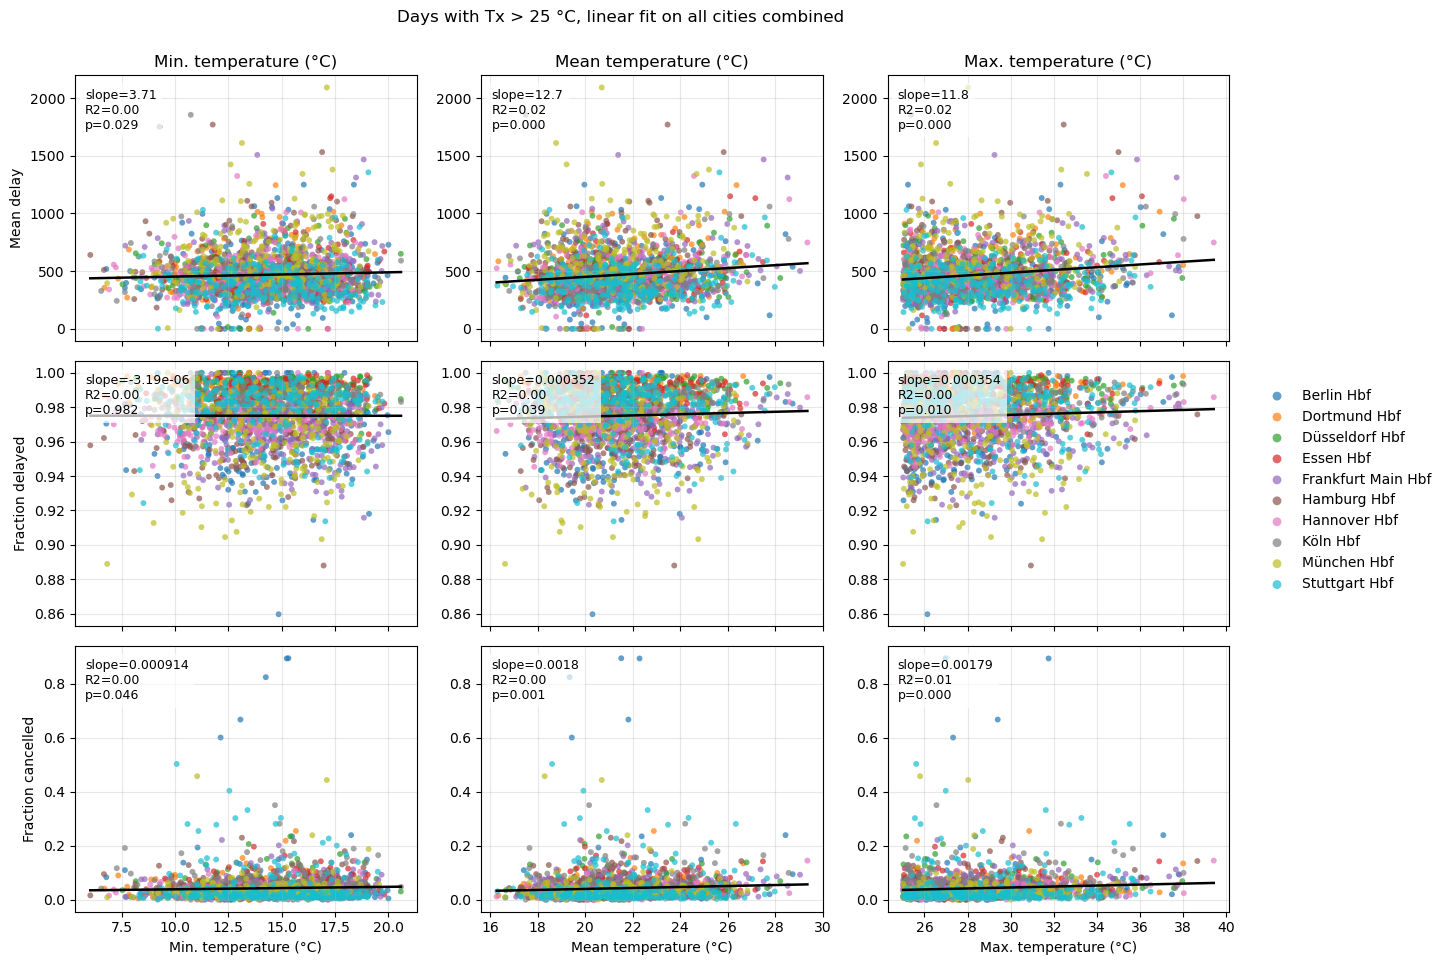

        y_variable x_variable    n   slope  intercept       r     R2  p_value  stderr_slope
        mean_delay         tn 2148  3.7119   415.4891  0.0471 0.0022   0.0289        1.6982
        mean_delay         tg 2148 12.6842   196.5580  0.1336 0.0179   0.0000        2.0309
        mean_delay         tx 2148 11.8241   132.0694  0.1551 0.0240   0.0000        1.6262
  fraction_delayed         tn 2148 -0.0000     0.9751 -0.0005 0.0000   0.9821        0.0001
  fraction_delayed         tg 2148  0.0004     0.9675  0.0444 0.0020   0.0395        0.0002
  fraction_delayed         tx 2148  0.0004     0.9650  0.0557 0.0031   0.0099        0.0001
fraction_cancelled         tn 2148  0.0009     0.0292  0.0430 0.0019   0.0462        0.0005
fraction_cancelled         tg 2148  0.0018     0.0036  0.0705 0.0050   0.0011        0.0006
fraction_cancelled         tx 2148  0.0018    -0.0086  0.0869 0.0075   0.0001        0.0004


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
TX_MIN = 25
ROWS = ["mean_delay", "fraction_delayed", "fraction_cancelled"]
ROW_LABELS = {"mean_delay": "Mean delay",
              "fraction_delayed": "Fraction delayed",
              "fraction_cancelled": "Fraction cancelled"}
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True)
data = data[data["tx"] > TX_MIN]

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

results = []

fig, axes = plt.subplots(len(ROWS), len(TEMP_COLS),
                         figsize=(4.2 * len(TEMP_COLS), 3.2 * len(ROWS)),
                         sharex="col", squeeze=False)

for i, row in enumerate(ROWS):
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        for city in cities:
            s = data[data["city"] == city]
            ax.scatter(s[var], s[row], s=18, alpha=0.7, edgecolor="none",
                       color=colors[city], label=city)

        # one fit on all cities combined
        sub = data[[var, row]].dropna()
        res = stats.linregress(sub[var], sub[row])
        xs = np.array([sub[var].min(), sub[var].max()])
        ax.plot(xs, res.intercept + res.slope * xs, color="k", lw=1.8)
        ax.text(0.03, 0.95,
                f"slope={res.slope:.3g}\nR2={res.rvalue**2:.2f}\np={res.pvalue:.3f}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(fc="white", ec="none", alpha=0.7))

        results.append({"y_variable": row, "x_variable": var, "n": len(sub),
                        "slope": res.slope, "intercept": res.intercept,
                        "r": res.rvalue, "R2": res.rvalue**2,
                        "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(ROW_LABELS[row])
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == len(ROWS) - 1:
            ax.set_xlabel(TEMP_LABELS[var])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
           markerscale=1.5, frameon=False)
fig.suptitle(f"Days with Tx > {TX_MIN} °C, linear fit on all cities combined", y=1.0)
fig.tight_layout()
plt.show()

summary = pd.DataFrame(results)
print(summary.round(4).to_string(index=False))

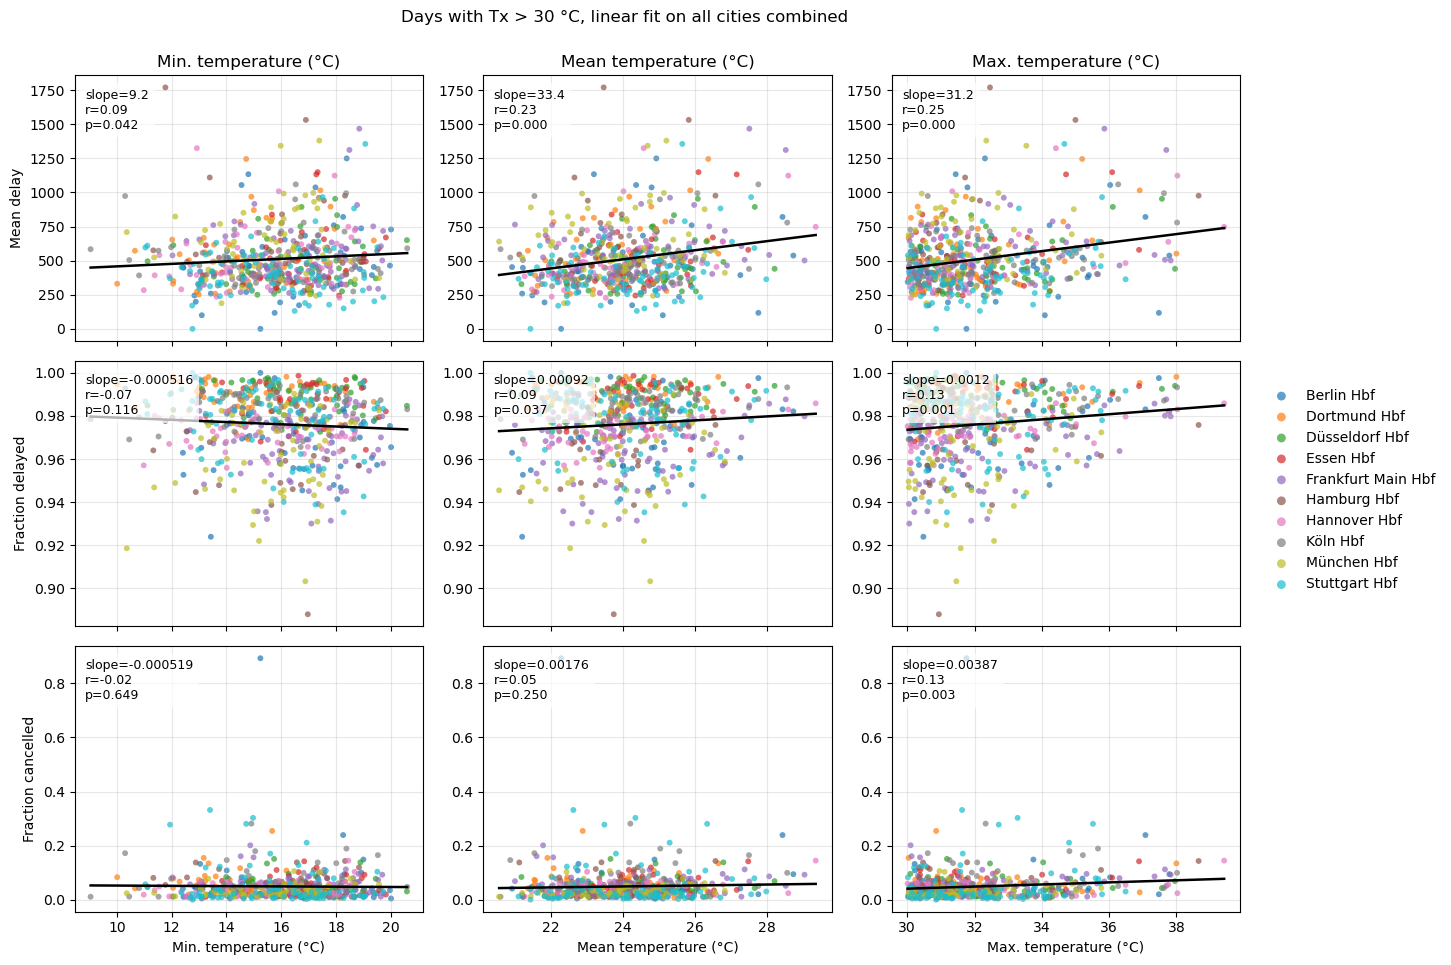

        y_variable x_variable   n   slope  intercept       r     R2  p_value  stderr_slope
        mean_delay         tn 570  9.1958   366.0077  0.0851 0.0072   0.0423        4.5178
        mean_delay         tg 570 33.3887  -291.9726  0.2300 0.0529   0.0000        5.9272
        mean_delay         tx 570 31.2430  -492.5282  0.2543 0.0647   0.0000        4.9853
  fraction_delayed         tn 570 -0.0005     0.9844 -0.0660 0.0044   0.1156        0.0003
  fraction_delayed         tg 570  0.0009     0.9540  0.0875 0.0077   0.0368        0.0004
  fraction_delayed         tx 570  0.0012     0.9376  0.1350 0.0182   0.0012        0.0004
fraction_cancelled         tn 570 -0.0005     0.0573 -0.0191 0.0004   0.6490        0.0011
fraction_cancelled         tg 570  0.0018     0.0066  0.0483 0.0023   0.2498        0.0015
fraction_cancelled         tx 570  0.0039    -0.0753  0.1252 0.0157   0.0028        0.0013


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
TX_MIN = 30
ROWS = ["mean_delay", "fraction_delayed", "fraction_cancelled"]
ROW_LABELS = {"mean_delay": "Mean delay",
              "fraction_delayed": "Fraction delayed",
              "fraction_cancelled": "Fraction cancelled"}
TEMP_COLS = ["tn", "tg", "tx"]
TEMP_LABELS = {"tn": "Min. temperature (°C)",
               "tg": "Mean temperature (°C)",
               "tx": "Max. temperature (°C)"}
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True)
data = data[data["tx"] > TX_MIN]

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

results = []

fig, axes = plt.subplots(len(ROWS), len(TEMP_COLS),
                         figsize=(4.2 * len(TEMP_COLS), 3.2 * len(ROWS)),
                         sharex="col", squeeze=False)

for i, row in enumerate(ROWS):
    for j, var in enumerate(TEMP_COLS):
        ax = axes[i, j]
        for city in cities:
            s = data[data["city"] == city]
            ax.scatter(s[var], s[row], s=18, alpha=0.7, edgecolor="none",
                       color=colors[city], label=city)

        # one fit on all cities combined
        sub = data[[var, row]].dropna()
        res = stats.linregress(sub[var], sub[row])
        xs = np.array([sub[var].min(), sub[var].max()])
        ax.plot(xs, res.intercept + res.slope * xs, color="k", lw=1.8)
        ax.text(0.03, 0.95,
                f"slope={res.slope:.3g}\nr={res.rvalue:.2f}\np={res.pvalue:.3f}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(fc="white", ec="none", alpha=0.7))

        results.append({"y_variable": row, "x_variable": var, "n": len(sub),
                        "slope": res.slope, "intercept": res.intercept,
                        "r": res.rvalue, "R2": res.rvalue**2,
                        "p_value": res.pvalue, "stderr_slope": res.stderr})

        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel(ROW_LABELS[row])
        if i == 0:
            ax.set_title(TEMP_LABELS[var])
        if i == len(ROWS) - 1:
            ax.set_xlabel(TEMP_LABELS[var])

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
           markerscale=1.5, frameon=False)
fig.suptitle(f"Days with Tx > {TX_MIN} °C, linear fit on all cities combined", y=1.0)
fig.tight_layout()
plt.show()

summary = pd.DataFrame(results)
print(summary.round(4).to_string(index=False))

### Go towards boxplots

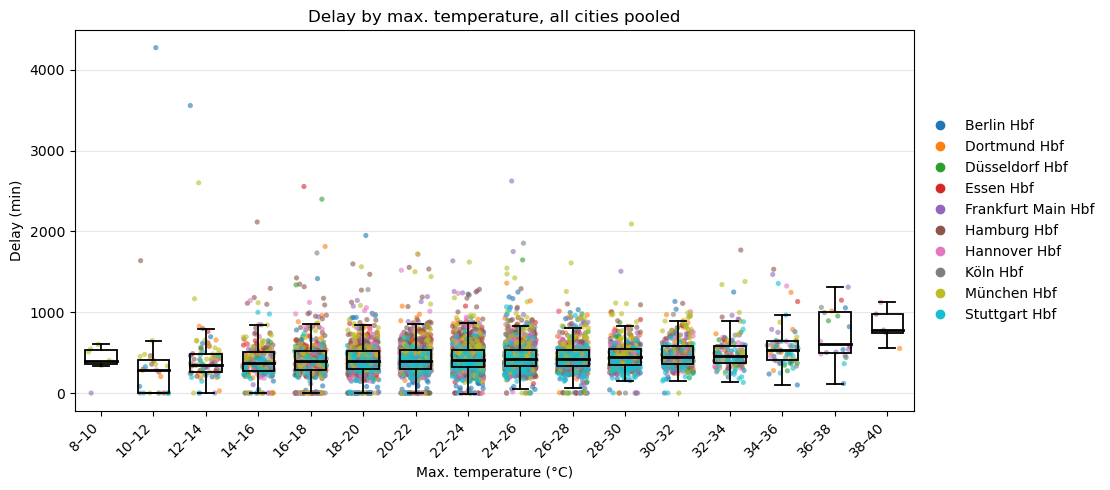

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
DELAY_VAR = "mean_delay"  # delay in min
BIN_WIDTH = 2             # °C
MIN_N = 5                 # min. samples per box, otherwise no box (points still shown)
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True).dropna(subset=["tx", DELAY_VAR])

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

# temperature bins
lo = np.floor(data["tx"].min() / BIN_WIDTH) * BIN_WIDTH
hi = np.ceil(data["tx"].max() / BIN_WIDTH) * BIN_WIDTH
if hi == lo:
    hi = lo + BIN_WIDTH
edges = np.arange(lo, hi + BIN_WIDTH, BIN_WIDTH)
data["tbin"] = pd.cut(data["tx"], bins=edges, right=False)
bins = [b for b in data["tbin"].cat.categories if (data["tbin"] == b).any()]
bin_idx = {b: i for i, b in enumerate(bins)}

fig, ax = plt.subplots(figsize=(max(8, 0.7 * len(bins)), 5))
rng = np.random.default_rng(0)

# points colored by city (drawn first, so boxes sit on top)
for city in cities:
    s = data[data["city"] == city]
    x = s["tbin"].map(bin_idx).astype(float).values
    x = x + rng.uniform(-0.3, 0.3, size=len(x))
    ax.scatter(x, s[DELAY_VAR], s=14, alpha=0.6, edgecolor="none",
               color=colors[city], zorder=2)

# one pooled box per temperature bin
pos, vals = [], []
for b in bins:
    v = data.loc[data["tbin"] == b, DELAY_VAR].values
    if len(v) >= MIN_N:
        pos.append(bin_idx[b])
        vals.append(v)
ax.boxplot(vals, positions=pos, widths=0.6, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="none", edgecolor="k", lw=1.3),
           whiskerprops=dict(color="k", lw=1.3),
           capprops=dict(color="k", lw=1.3),
           medianprops=dict(color="k", lw=2), zorder=3)

ax.set_xticks(range(len(bins)))
ax.set_xticklabels([f"{b.left:g}–{b.right:g}" for b in bins], rotation=45, ha="right")
ax.set_xlabel("Max. temperature (°C)")
ax.set_ylabel("Delay (min)")
ax.set_title("Delay by max. temperature, all cities pooled")
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=[Line2D([], [], marker="o", ls="", color=colors[c], label=c)
                   for c in cities],
          loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout()
plt.show()

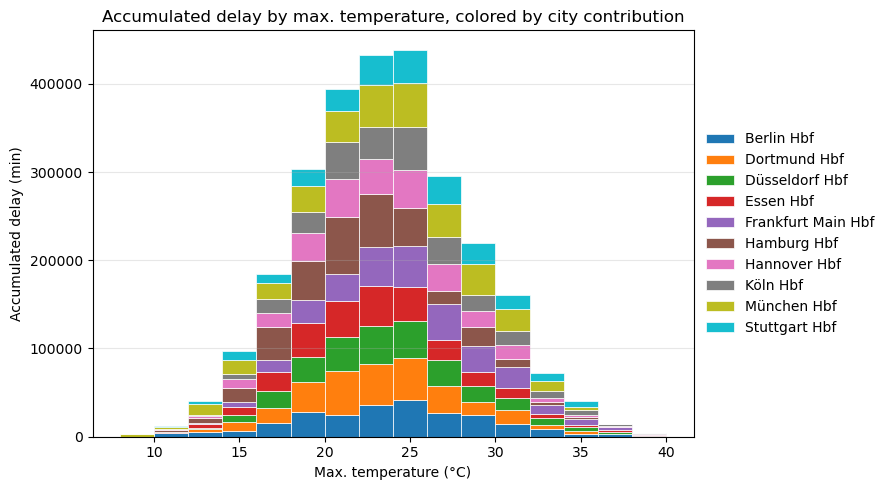

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
DELAY_VAR = "mean_delay"  # <- column with the delay (min) that gets summed
BIN_WIDTH = 2             # °C
PER_DAY = False           # True: divide each bin's sum by number of days in that bin
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True).dropna(subset=["tx", DELAY_VAR])

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

# temperature bins
lo = np.floor(data["tx"].min() / BIN_WIDTH) * BIN_WIDTH
hi = np.ceil(data["tx"].max() / BIN_WIDTH) * BIN_WIDTH
if hi == lo:
    hi = lo + BIN_WIDTH
edges = np.arange(lo, hi + BIN_WIDTH, BIN_WIDTH)
data["tbin"] = pd.cut(data["tx"], bins=edges, right=False)

# summed delay per bin and city
sums = (data.groupby(["tbin", "city"], observed=False)[DELAY_VAR]
            .sum().unstack("city").reindex(columns=cities).fillna(0))
if PER_DAY:
    n_days = data.groupby("tbin", observed=False).size().replace(0, np.nan)
    sums = sums.div(n_days, axis=0).fillna(0)

# stacked histogram
fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(sums))
for city in cities:
    ax.bar(edges[:-1], sums[city].values, width=BIN_WIDTH, align="edge",
           bottom=bottom, color=colors[city], edgecolor="white", lw=0.5,
           label=city)
    bottom += sums[city].values

ax.set_xlabel("Max. temperature (°C)")
ax.set_ylabel("Summed delay per day (min)" if PER_DAY else "Accumulated delay (min)")
ax.set_title("Accumulated delay by max. temperature, colored by city contribution")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout()
plt.show()

Number of entries per Tx bin and city:
city   Berlin Hbf  Dortmund Hbf  Düsseldorf Hbf  Essen Hbf  Frankfurt Main Hbf  Hamburg Hbf  Hannover Hbf  Köln Hbf  München Hbf  Stuttgart Hbf  total
8–10            0             0               0          0                   1            0             0         0            6              0      7
10–12           2             2               1          2                   0            5             2         1            8              5     28
12–14           6             7               4         10                   6           14             7         5           23             12     94
14–16          20            23              20         24                  16           27            26        17           34             30    237
16–18          40            42              44         51                  36           73            39        41           42             30    438
18–20          75            78              73        

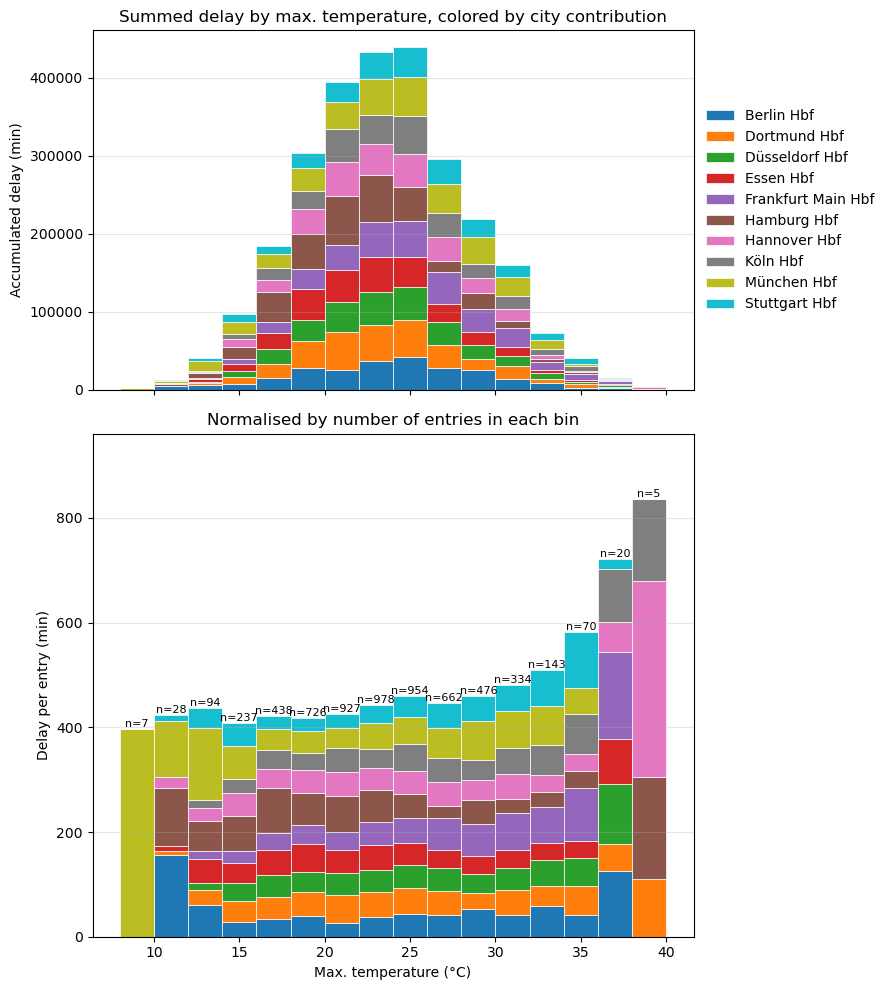

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
DELAY_VAR = "mean_delay"  # <- column with the delay (min) that gets summed
BIN_WIDTH = 2             # °C
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True).dropna(subset=["tx", DELAY_VAR])

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

# temperature bins
lo = np.floor(data["tx"].min() / BIN_WIDTH) * BIN_WIDTH
hi = np.ceil(data["tx"].max() / BIN_WIDTH) * BIN_WIDTH
if hi == lo:
    hi = lo + BIN_WIDTH
edges = np.arange(lo, hi + BIN_WIDTH, BIN_WIDTH)
data["tbin"] = pd.cut(data["tx"], bins=edges, right=False)

# summed delay and number of entries per bin and city
grp = data.groupby(["tbin", "city"], observed=False)[DELAY_VAR]
sums = grp.sum().unstack("city").reindex(columns=cities).fillna(0)
counts = grp.size().unstack("city").reindex(columns=cities).fillna(0).astype(int)
n_total = counts.sum(axis=1)

# normalised: each city's sum divided by ALL entries in the bin
# -> segments add up to the mean delay per entry in that bin
norm = sums.div(n_total.replace(0, np.nan), axis=0).fillna(0)

# ---- print number of entries ----
table = counts.copy()
table["total"] = n_total
table.index = [f"{b.left:g}–{b.right:g}" for b in table.index]
print("Number of entries per Tx bin and city:")
print(table.to_string())
print(f"\nTotal entries: {n_total.sum()}")

# ---- plots ----
def stacked(ax, values):
    bottom = np.zeros(len(values))
    for city in cities:
        ax.bar(edges[:-1], values[city].values, width=BIN_WIDTH, align="edge",
               bottom=bottom, color=colors[city], edgecolor="white", lw=0.5,
               label=city)
        bottom += values[city].values
    return bottom

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 10), sharex=True,
                               gridspec_kw={"height_ratios": [1, 1.4]})

stacked(ax1, sums)
ax1.set_ylabel("Accumulated delay (min)")
ax1.set_title("Summed delay by max. temperature, colored by city contribution")

tops = stacked(ax2, norm)
for x, top, n in zip(edges[:-1], tops, n_total.values):
    ax2.text(x + BIN_WIDTH / 2, top, f"n={n}", ha="center", va="bottom", fontsize=8)
ax2.set_ylim(0, tops.max() * 1.15)   # headroom above the tallest bar
ax2.set_ylabel("Delay per entry (min)")
ax2.set_xlabel("Max. temperature (°C)")
ax2.set_title("Normalised by number of entries in each bin")

for ax in (ax1, ax2):
    ax.grid(axis="y", alpha=0.3)
ax1.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout()
plt.show()

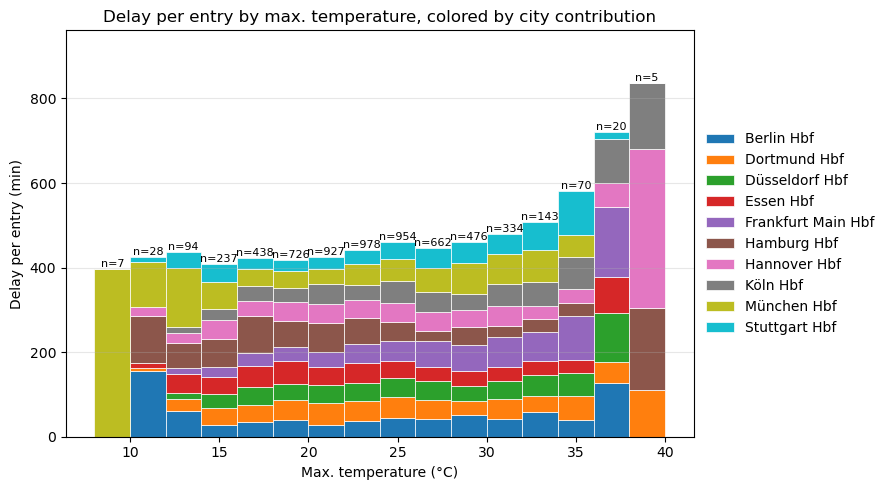

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

tops = stacked(ax, norm)
for x, top, n in zip(edges[:-1], tops, n_total.values):
    ax.text(x + BIN_WIDTH / 2, top, f"n={n}", ha="center", va="bottom", fontsize=8)

ax.set_ylim(0, tops.max() * 1.15)   # headroom above the tallest bar
ax.set_ylabel("Delay per entry (min)")
ax.set_xlabel("Max. temperature (°C)")
ax.set_title("Delay per entry by max. temperature, colored by city contribution")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)

fig.tight_layout()
plt.show()

Number of entries per city and bin:
tbin                Tx < 30 °C  Tx ≥ 30 °C
city                                      
Berlin Hbf                 552          57
Dortmund Hbf               558          52
Düsseldorf Hbf             552          58
Essen Hbf                  571          39
Frankfurt Main Hbf         527          83
Hamburg Hbf                587          23
Hannover Hbf               559          51
Köln Hbf                   544          66
München Hbf                547          63
Stuttgart Hbf              530          80

Total entries: 6099


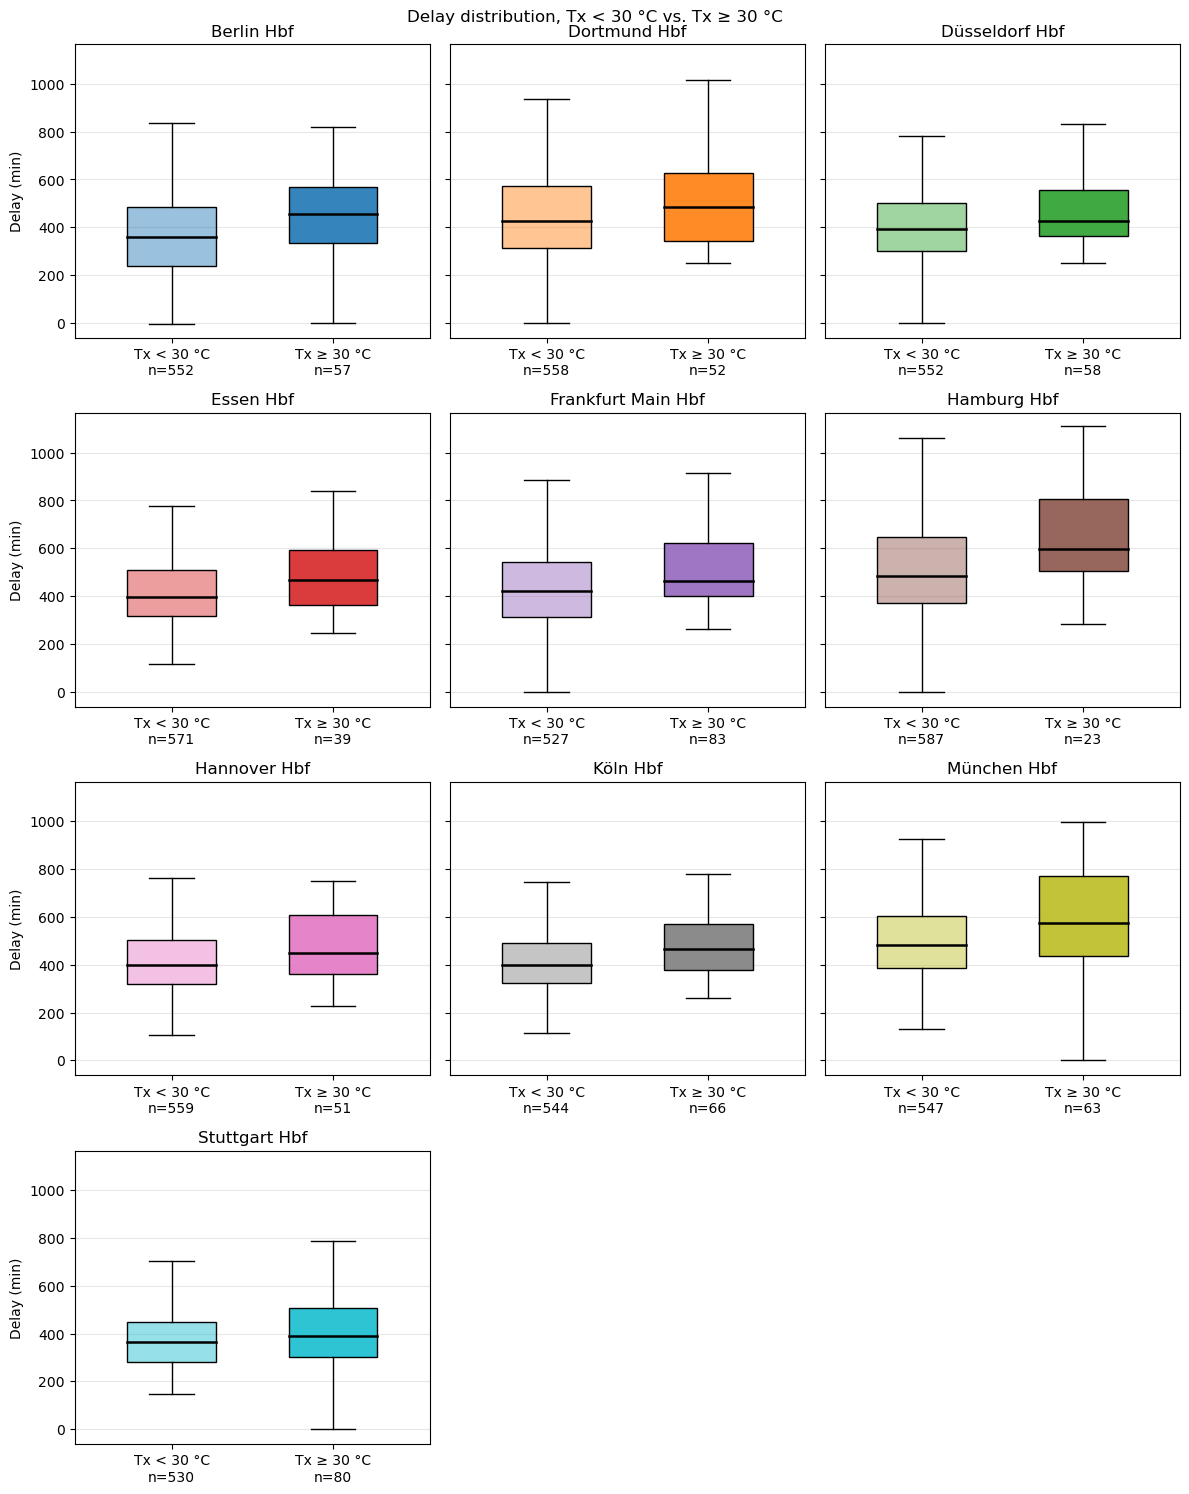

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
DELAY_VAR = "mean_delay"  # <- column with the delay (min)
THRESHOLD = 30            # °C; below -> "cold" box, at or above -> "hot" box
NCOLS = 3                 # panels per row
SHOW_FLIERS = True        # show outliers
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True).dropna(subset=["tx", DELAY_VAR])

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

labels = [f"Tx < {THRESHOLD} °C", f"Tx ≥ {THRESHOLD} °C"]
data["tbin"] = np.where(data["tx"] < THRESHOLD, labels[0], labels[1])

# ---- print number of entries ----
counts = (data.groupby(["city", "tbin"]).size()
              .unstack("tbin").reindex(index=cities, columns=labels)
              .fillna(0).astype(int))
print("Number of entries per city and bin:")
print(counts.to_string())
print(f"\nTotal entries: {counts.values.sum()}")

# ---- plot ----
nrows = int(np.ceil(len(cities) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(4 * NCOLS, 3.8 * nrows),
                         squeeze=False, sharey=True)

for ax, city in zip(axes.ravel(), cities):
    s = data[data["city"] == city]
    pos, vals, alphas = [], [], []
    for k, lab in enumerate(labels):
        v = s.loc[s["tbin"] == lab, DELAY_VAR].values
        if len(v) > 0:
            pos.append(k)
            vals.append(v)
            alphas.append(0.45 if k == 0 else 0.9)   # cold lighter, hot full color
    if vals:
        bp = ax.boxplot(vals, positions=pos, widths=0.55, patch_artist=True,
                        showfliers=False,
                        medianprops=dict(color="k", lw=1.8),
                        flierprops=dict(marker="o", markersize=3,
                                        markerfacecolor="grey",
                                        markeredgecolor="none", alpha=0.6))
        for patch, a in zip(bp["boxes"], alphas):
            patch.set_facecolor(to_rgba(colors[city], a))
            patch.set_edgecolor("k")
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"{lab}\nn={counts.loc[city, lab]}" for lab in labels])
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(city)
    ax.grid(axis="y", alpha=0.3)

for ax in axes.ravel()[len(cities):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("Delay (min)")
fig.suptitle(f"Delay distribution, Tx < {THRESHOLD} °C vs. Tx ≥ {THRESHOLD} °C")
fig.tight_layout()
plt.show()

Number of entries per city and bin:
tbin                Tx < 35 °C  Tx ≥ 35 °C
city                                      
Berlin Hbf                 602           7
Dortmund Hbf               606           4
Düsseldorf Hbf             607           3
Essen Hbf                  608           2
Frankfurt Main Hbf         601           9
Hamburg Hbf                607           3
Hannover Hbf               604           6
Köln Hbf                   602           8
München Hbf                608           2
Stuttgart Hbf              604           6

Total entries: 6099


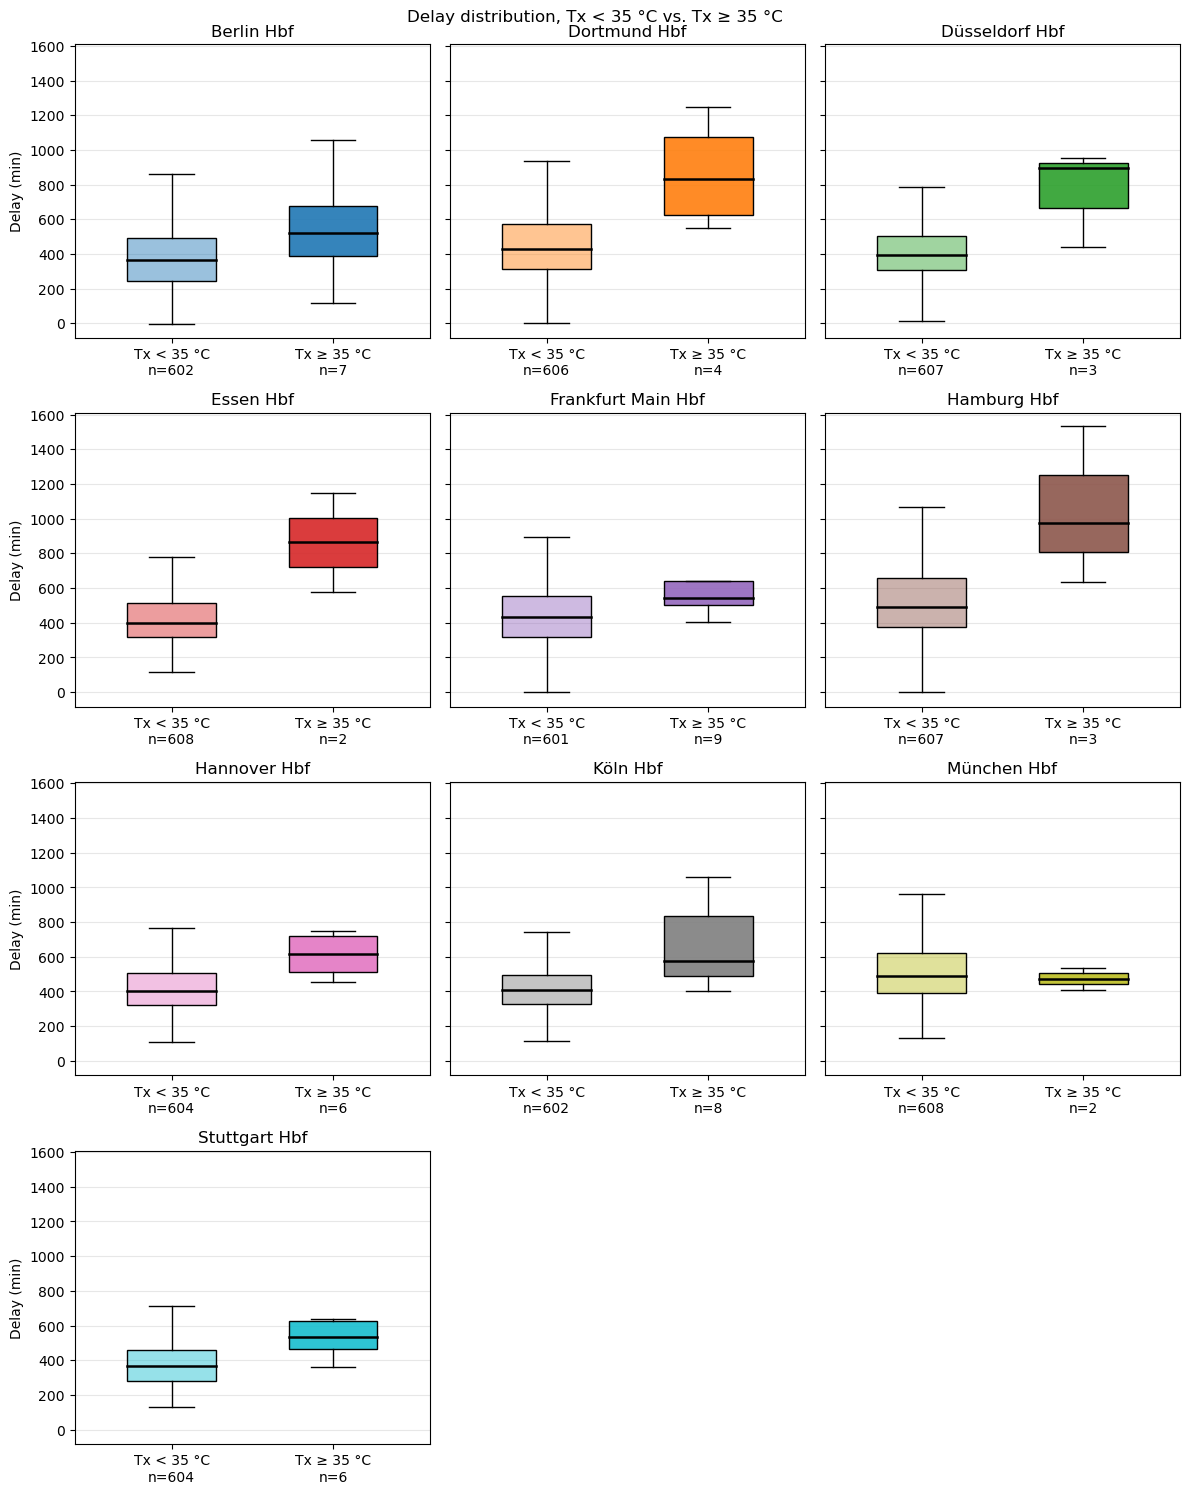

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
DELAY_VAR = "mean_delay"  # <- column with the delay (min)
THRESHOLD = 35            # °C; below -> "cold" box, at or above -> "hot" box
NCOLS = 3                 # panels per row
SHOW_FLIERS = True        # show outliers
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True).dropna(subset=["tx", DELAY_VAR])

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

labels = [f"Tx < {THRESHOLD} °C", f"Tx ≥ {THRESHOLD} °C"]
data["tbin"] = np.where(data["tx"] < THRESHOLD, labels[0], labels[1])

# ---- print number of entries ----
counts = (data.groupby(["city", "tbin"]).size()
              .unstack("tbin").reindex(index=cities, columns=labels)
              .fillna(0).astype(int))
print("Number of entries per city and bin:")
print(counts.to_string())
print(f"\nTotal entries: {counts.values.sum()}")

# ---- plot ----
nrows = int(np.ceil(len(cities) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(4 * NCOLS, 3.8 * nrows),
                         squeeze=False, sharey=True)

for ax, city in zip(axes.ravel(), cities):
    s = data[data["city"] == city]
    pos, vals, alphas = [], [], []
    for k, lab in enumerate(labels):
        v = s.loc[s["tbin"] == lab, DELAY_VAR].values
        if len(v) > 0:
            pos.append(k)
            vals.append(v)
            alphas.append(0.45 if k == 0 else 0.9)   # cold lighter, hot full color
    if vals:
        bp = ax.boxplot(vals, positions=pos, widths=0.55, patch_artist=True,
                        showfliers=False,
                        medianprops=dict(color="k", lw=1.8),
                        flierprops=dict(marker="o", markersize=3,
                                        markerfacecolor="grey",
                                        markeredgecolor="none", alpha=0.6))
        for patch, a in zip(bp["boxes"], alphas):
            patch.set_facecolor(to_rgba(colors[city], a))
            patch.set_edgecolor("k")
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"{lab}\nn={counts.loc[city, lab]}" for lab in labels])
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(city)
    ax.grid(axis="y", alpha=0.3)

for ax in axes.ravel()[len(cities):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("Delay (min)")
fig.suptitle(f"Delay distribution, Tx < {THRESHOLD} °C vs. Tx ≥ {THRESHOLD} °C")
fig.tight_layout()
plt.show()

Number of entries per city and bin:
tbin                Tx < 30 °C  Tx ≥ 30 °C
city                                      
Berlin Hbf                 553          57
Dortmund Hbf               558          52
Düsseldorf Hbf             552          58
Essen Hbf                  571          39
Frankfurt Main Hbf         527          83
Hamburg Hbf                587          23
Hannover Hbf               559          51
Köln Hbf                   544          66
München Hbf                547          63
Stuttgart Hbf              530          80

Total entries: 6100


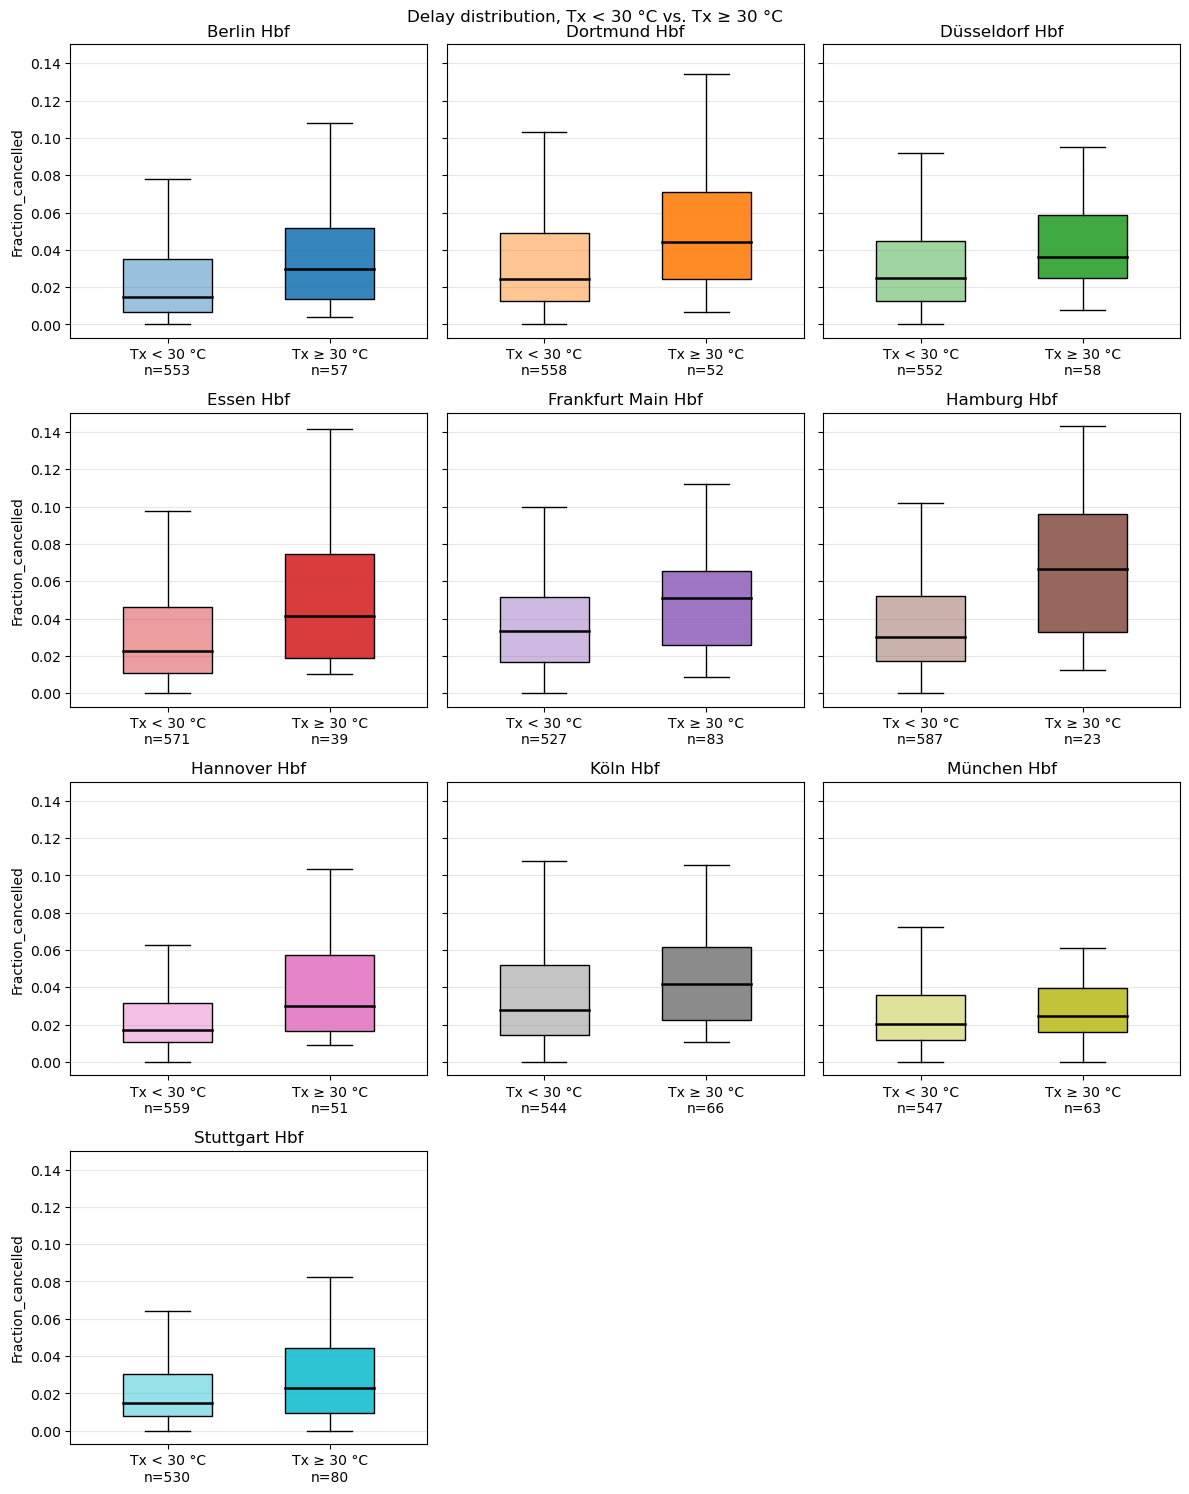

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# ---- settings ----
csv_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_2022_2025")
DELAY_VAR = "fraction_cancelled"  # <- column with the delay (min)
THRESHOLD = 30            # °C; below -> "cold" box, at or above -> "hot" box
NCOLS = 3                 # panels per row
SHOW_FLIERS = True        # show outliers
# ------------------

frames = []
for f in sorted(csv_dir.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["date"])
    d["city"] = f.stem.replace("_", " ")
    frames.append(d)
data = pd.concat(frames, ignore_index=True).dropna(subset=["tx", DELAY_VAR])

cities = sorted(data["city"].unique())
cmap = plt.get_cmap("tab10")
colors = {c: cmap(i % 10) for i, c in enumerate(cities)}

labels = [f"Tx < {THRESHOLD} °C", f"Tx ≥ {THRESHOLD} °C"]
data["tbin"] = np.where(data["tx"] < THRESHOLD, labels[0], labels[1])

# ---- print number of entries ----
counts = (data.groupby(["city", "tbin"]).size()
              .unstack("tbin").reindex(index=cities, columns=labels)
              .fillna(0).astype(int))
print("Number of entries per city and bin:")
print(counts.to_string())
print(f"\nTotal entries: {counts.values.sum()}")

# ---- plot ----
nrows = int(np.ceil(len(cities) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(4 * NCOLS, 3.8 * nrows),
                         squeeze=False, sharey=True)

for ax, city in zip(axes.ravel(), cities):
    s = data[data["city"] == city]
    pos, vals, alphas = [], [], []
    for k, lab in enumerate(labels):
        v = s.loc[s["tbin"] == lab, DELAY_VAR].values
        if len(v) > 0:
            pos.append(k)
            vals.append(v)
            alphas.append(0.45 if k == 0 else 0.9)   # cold lighter, hot full color
    if vals:
        bp = ax.boxplot(vals, positions=pos, widths=0.55, patch_artist=True,
                        showfliers=False,
                        medianprops=dict(color="k", lw=1.8),
                        flierprops=dict(marker="o", markersize=3,
                                        markerfacecolor="grey",
                                        markeredgecolor="none", alpha=0.6))
        for patch, a in zip(bp["boxes"], alphas):
            patch.set_facecolor(to_rgba(colors[city], a))
            patch.set_edgecolor("k")
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"{lab}\nn={counts.loc[city, lab]}" for lab in labels])
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(city)
    ax.grid(axis="y", alpha=0.3)

for ax in axes.ravel()[len(cities):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("Fraction_cancelled")
fig.suptitle(f"Delay distribution, Tx < {THRESHOLD} °C vs. Tx ≥ {THRESHOLD} °C")
fig.tight_layout()
plt.show()